# Détection de régimes de marché avec un Hidden Markov Model

## Objectif

Dans ce notebook, nous allons reproduire l'idée principale de l'article : utiliser un **Hidden Markov Model (HMM)** pour détecter des **régimes de marché** à partir des rendements du **SPY**.

L'idée est la suivante :

- le marché ne se comporte pas toujours de la même manière ;
- il existe des phases calmes et des phases plus volatiles ;
- ces phases peuvent être vues comme des **états cachés** ;
- un modèle HMM permet d'inférer ces états à partir d'une série observable, ici les rendements journaliers.

Le but est ensuite d'utiliser ces régimes comme **filtre de risque** pour améliorer une stratégie simple de trading.

## Rappel sur le SPY

Le **SPY** est un ETF qui réplique l'indice **S\&P 500**.  
Il est souvent utilisé comme proxy du marché actions américain.

## Rappel sur la stratégie de l'article

L'article utilise une stratégie de suivi de tendance volontairement simple, fondée sur deux moyennes mobiles simples :

- une moyenne mobile simple à 10 jours ;
- une moyenne mobile simple à 30 jours.

Si l'on note :

$$
SMA_{10}(t) = \frac{1}{10}\sum_{i=0}^{9} P_{t-i}
$$

et

$$
SMA_{30}(t) = \frac{1}{30}\sum_{i=0}^{29} P_{t-i}
$$

alors :

- on achète lorsque $SMA_{10}(t) > SMA_{30}(t)$ ;
- on sort lorsque $SMA_{10}(t) < SMA_{30}(t)$.

Dans cette première partie, nous allons surtout préparer les données et entraîner le HMM sur les rendements du SPY.

## Imports et récupération des données

Dans l'article original, les données sont chargées depuis un fichier CSV.  
Ici, nous allons récupérer directement les données historiques du SPY avec `yfinance`, ce qui simplifie le travail dans un notebook.

Nous allons ensuite :

1. récupérer l'historique du SPY ;
2. remettre les colonnes dans un format simple ;
3. calculer les rendements journaliers ;
4. restreindre l'échantillon jusqu'au 31 décembre 2004, comme dans l'article.

In [20]:
%pip install yfinance hmmlearn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from hmmlearn.hmm import GaussianHMM
from matplotlib.dates import DateFormatter, YearLocator

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

In [22]:
# Téléchargement des données du SPY
spy = yf.download("SPY", start="1993-01-01", end="2005-01-01")

# Si yfinance renvoie des colonnes en MultiIndex, on les simplifie
if isinstance(spy.columns, pd.MultiIndex):
    spy.columns = spy.columns.get_level_values(0)

# Calcul des rendements journaliers
spy["Returns"] = spy["Close"].pct_change()

# Suppression de la première ligne manquante
spy.dropna(inplace=True)

# Restriction à la période d'entraînement de l'article
spy = spy.loc[: "2004-12-31"].copy()

print(spy.shape)
spy.head()

[*********************100%***********************]  1 of 1 completed

(3004, 6)


Price,Close,High,Low,Open,Volume,Returns
Date,,,,,,
1993-02-01,24.347334,24.347334,24.192584,24.192584,480500,0.007113
1993-02-02,24.398914,24.416109,24.278553,24.330137,201300,0.002119
1993-02-03,24.656836,24.674030,24.416113,24.433308,529400,0.010571
1993-02-04,24.759998,24.811582,24.467693,24.742804,531500,0.004184
1993-02-05,24.742781,24.794364,24.605225,24.742781,492100,-0.000695


## Rendements journaliers

Le modèle HMM sera entraîné sur les rendements journaliers du SPY.

Le rendement simple à la date $t$ est donné par :

$$
r_t = \frac{P_t}{P_{t-1}} - 1
$$

où $P_t$ désigne ici le prix de clôture.

En pratique, nous avons ajouté une colonne `Returns` au DataFrame, qui contient cette série.  
Nous allons maintenant visualiser :

- le prix du SPY ;
- les rendements journaliers ;
- la distribution empirique des rendements.

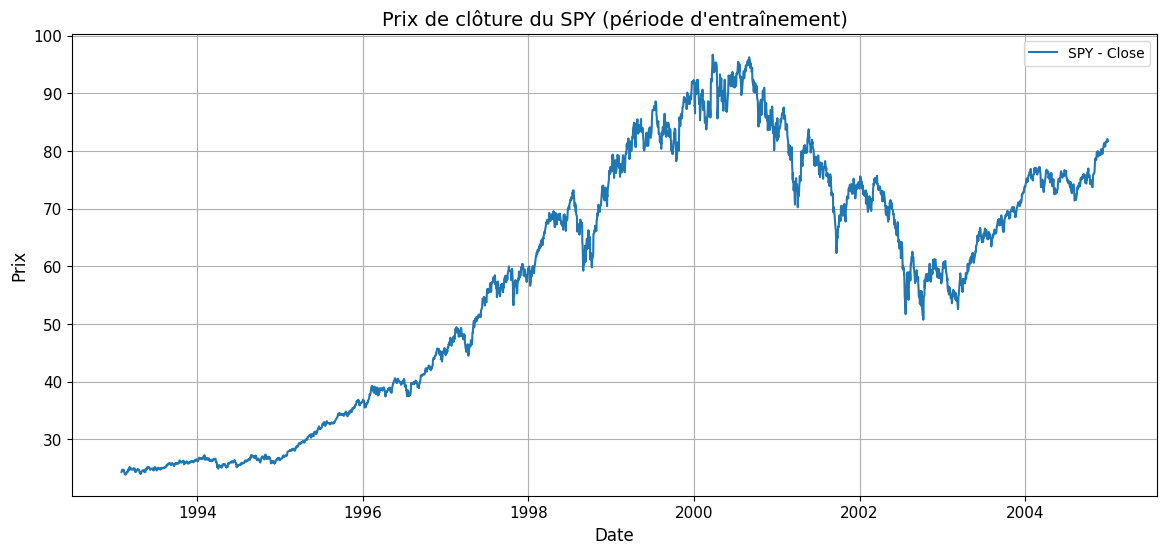

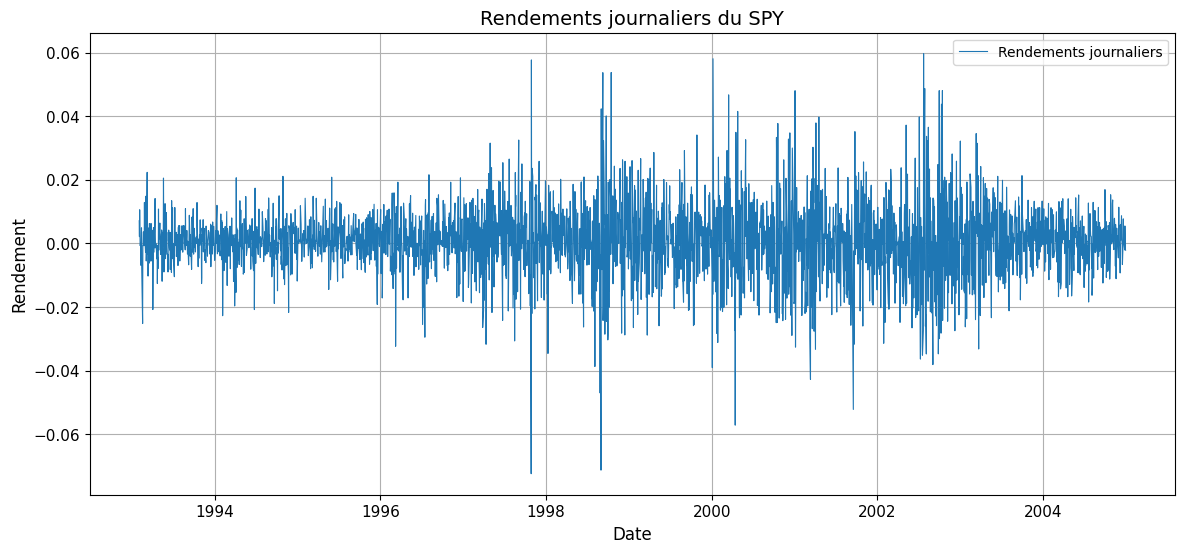

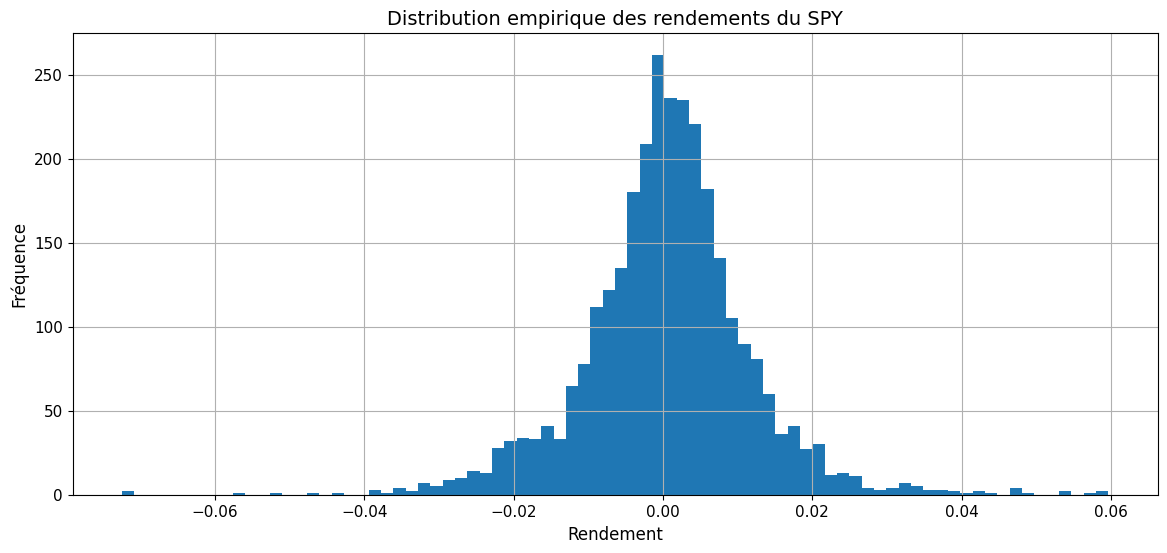

In [23]:
fig, ax = plt.subplots()
ax.plot(spy.index, spy["Close"], label="SPY - Close")
ax.set_title("Prix de clôture du SPY (période d'entraînement)")
ax.set_xlabel("Date")
ax.set_ylabel("Prix")
ax.legend()
ax.xaxis.set_major_locator(YearLocator(2))
ax.xaxis.set_major_formatter(DateFormatter("%Y"))
plt.show()

fig, ax = plt.subplots()
ax.plot(spy.index, spy["Returns"], linewidth=0.8, label="Rendements journaliers")
ax.set_title("Rendements journaliers du SPY")
ax.set_xlabel("Date")
ax.set_ylabel("Rendement")
ax.legend()
ax.xaxis.set_major_locator(YearLocator(2))
ax.xaxis.set_major_formatter(DateFormatter("%Y"))
plt.show()

fig, ax = plt.subplots()
ax.hist(spy["Returns"], bins=80)
ax.set_title("Distribution empirique des rendements du SPY")
ax.set_xlabel("Rendement")
ax.set_ylabel("Fréquence")
plt.show()

## Entraînement du Hidden Markov Model

Nous allons maintenant entraîner un **Gaussian Hidden Markov Model** sur la série des rendements.

Un HMM suppose l'existence d'une suite d'états cachés :

$$
S_t \in \{1,2,\dots,K\}
$$

que l'on n'observe pas directement.

En revanche, on observe ici les rendements $r_t$, supposés dépendre de l'état courant.  
Dans un **Gaussian HMM**, la distribution des observations conditionnellement à l'état caché est gaussienne.

Comme dans l'article, nous allons utiliser :

- un modèle à **2 états cachés** ;
- un grand nombre d'itérations pour assurer la convergence.

La bibliothèque `hmmlearn` attend une matrice d'entrée de dimension :

$$
(T, n)
$$

où :

- $T$ est le nombre d'observations ;
- $n$ est le nombre de variables observées.

Ici, comme nous n'utilisons que les rendements, nous avons :

$$
n = 1
$$

et nous devons donc transformer la série des rendements en matrice colonne.

In [24]:
# Mise en forme des rendements pour hmmlearn
rets = np.column_stack([spy["Returns"]])

# Création et entraînement du modèle HMM
hmm_model = GaussianHMM(
    n_components=2,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

hmm_model.fit(rets)

print("Modèle entraîné.")
print("Score du modèle :", hmm_model.score(rets))

Modèle entraîné.
Score du modèle : 9580.328254199998


## Prédiction des régimes cachés

Une fois le modèle entraîné, nous pouvons demander au HMM de prédire, pour chaque date, l'état caché le plus probable.

Nous obtenons donc une série d'étiquettes :

$$
\hat{S}_t \in \{0,1\}
$$

puisque nous avons choisi ici un modèle à deux régimes.

Nous allons ajouter cette information au DataFrame afin de visualiser les périodes associées à chaque régime.

In [25]:
hidden_states = hmm_model.predict(rets)

spy["State"] = hidden_states

spy[["Close", "Returns", "State"]].head()

Price,Close,Returns,State
Date,,,
1993-02-01,24.347334,0.007113,0
1993-02-02,24.398914,0.002119,0
1993-02-03,24.656836,0.010571,0
1993-02-04,24.759998,0.004184,0
1993-02-05,24.742781,-0.000695,0


## Visualisation des régimes de marché

Nous allons maintenant représenter les régimes détectés par le modèle.

L'idée est de colorer les observations selon l'état caché prédit.  
Cela permet de voir si le HMM distingue bien des périodes de comportements différents sur le marché.

Nous allons produire :

1. un nuage de points du prix du SPY, coloré par régime ;
2. un nuage de points des rendements, coloré par régime.

Cette visualisation permet déjà de repérer si un état semble correspondre à un régime plus calme et l'autre à un régime plus agité.

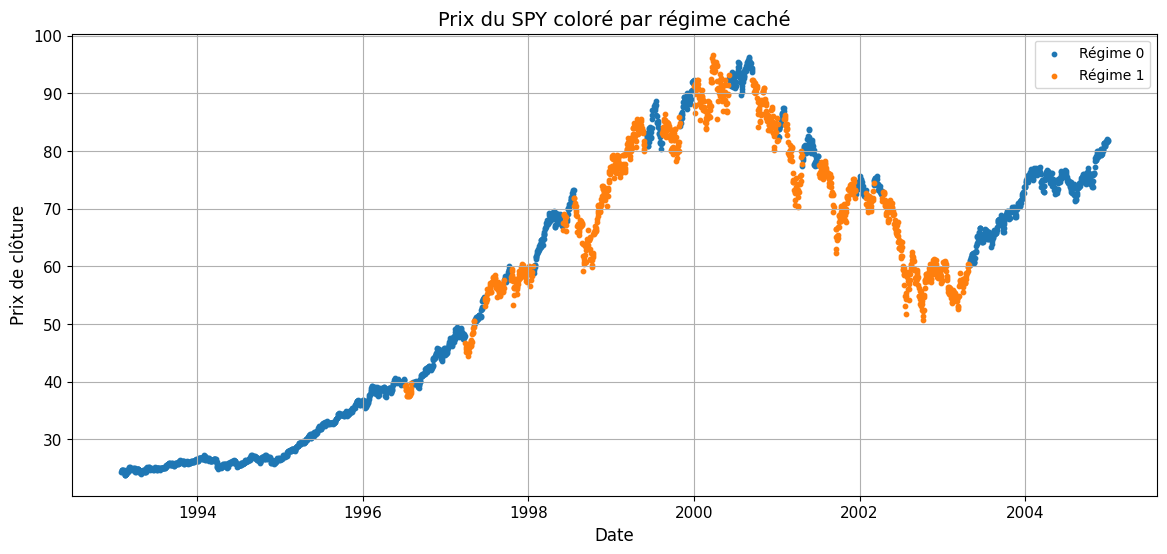

In [26]:
fig, ax = plt.subplots()

for state in sorted(spy["State"].unique()):
    mask = spy["State"] == state
    ax.scatter(
        spy.index[mask],
        spy.loc[mask, "Close"],
        s=10,
        label=f"Régime {state}"
    )

ax.set_title("Prix du SPY coloré par régime caché")
ax.set_xlabel("Date")
ax.set_ylabel("Prix de clôture")
ax.legend()
ax.xaxis.set_major_locator(YearLocator(2))
ax.xaxis.set_major_formatter(DateFormatter("%Y"))
plt.show()

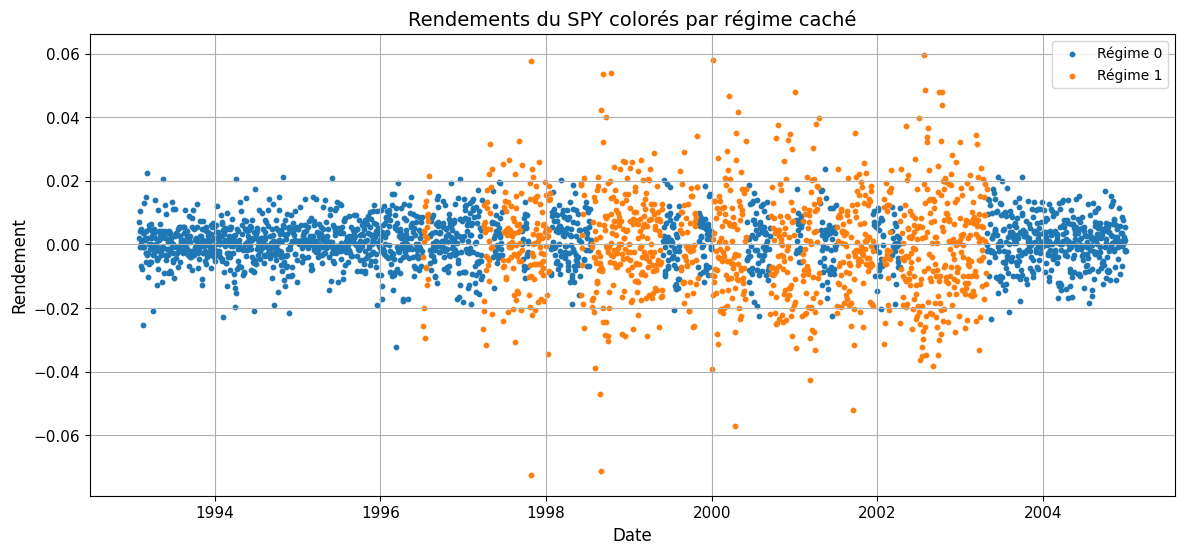

In [27]:
fig, ax = plt.subplots()

for state in sorted(spy["State"].unique()):
    mask = spy["State"] == state
    ax.scatter(
        spy.index[mask],
        spy.loc[mask, "Returns"],
        s=10,
        label=f"Régime {state}"
    )

ax.set_title("Rendements du SPY colorés par régime caché")
ax.set_xlabel("Date")
ax.set_ylabel("Rendement")
ax.legend()
ax.xaxis.set_major_locator(YearLocator(2))
ax.xaxis.set_major_formatter(DateFormatter("%Y"))
plt.show()

## Statistiques par régime

Pour interpréter économiquement les états détectés, il est utile de calculer quelques statistiques descriptives pour chaque régime :

- le nombre d'observations ;
- la moyenne des rendements ;
- l'écart-type des rendements.

En particulier, l'écart-type permet d'identifier le régime le plus volatil.

In [28]:
state_stats = spy.groupby("State")["Returns"].agg(["count", "mean", "std"])
state_stats

,count,mean,std
State,,,
0,1908,0.000807,0.007154
1,1096,-0.000120,0.016062


## Interprétation des résultats obtenus

Les résultats du HMM sont cohérents et déjà très intéressants.

### 1. Lecture générale des graphiques

Le graphique du prix du SPY montre une évolution de long terme globalement haussière entre 1993 et 2004, avec plusieurs phases bien distinctes :

- une phase de progression relativement régulière au milieu des années 1990 ;
- une accélération haussière à la fin des années 1990 ;
- une période plus instable autour de l'éclatement de la bulle internet ;
- une reprise progressive vers 2003-2004.

Le graphique des rendements journaliers montre clairement que la volatilité n'est pas constante dans le temps.  
Certaines périodes présentent des fluctuations faibles, tandis que d'autres affichent des variations beaucoup plus fortes, avec plusieurs pics extrêmes positifs et négatifs.

L'histogramme des rendements confirme que la distribution est centrée autour de zéro, mais avec des queues épaisses, ce qui est classique pour des rendements financiers.

### 2. Lecture des régimes détectés

Le modèle HMM à deux états a séparé les observations en deux régimes :

- **Régime 0**
- **Régime 1**

D'après les statistiques calculées :

- **Régime 0** :
  - nombre d'observations : $1908$
  - rendement moyen : $0.000807$
  - écart-type : $0.007154$

- **Régime 1** :
  - nombre d'observations : $1096$
  - rendement moyen : $-0.000120$
  - écart-type : $0.016062$

### 3. Interprétation économique des deux états

L'écart-type du régime 1 est nettement supérieur à celui du régime 0 :

$$
0.016062 > 0.007154
$$

Cela signifie que le **régime 1** correspond à un régime de **forte volatilité**.

À l'inverse, le **régime 0** correspond à un régime de **faible volatilité**, plus stable.

On remarque aussi que :

- le régime 0 possède un rendement moyen positif ;
- le régime 1 possède un rendement moyen légèrement négatif.

Autrement dit :

- le **régime 0** semble être un régime plus favorable, plus calme, plus "constructif" pour une stratégie directionnelle ;
- le **régime 1** semble être un régime plus risqué, plus instable, et moins porteur en moyenne.

### 4. Validation visuelle

Les graphiques colorés par régime confirment cette lecture :

- lorsque les points appartiennent au **régime 0**, les rendements restent en général plus proches de zéro ;
- lorsque les points appartiennent au **régime 1**, la dispersion des rendements est beaucoup plus forte.

Sur le graphique du prix, le régime 1 apparaît davantage pendant certaines zones de tension ou de turbulence du marché, ce qui est exactement ce que l'on voulait détecter.

### 5. Conclusion pour la suite

Cette séparation est essentielle pour la logique de l'article.

L'idée n'est pas simplement de classifier le passé, mais d'utiliser ensuite cette information comme **filtre de risque** :

- autoriser les prises de position lorsque le marché est dans un régime calme ;
- éviter ou bloquer certains trades lorsque le marché est dans un régime de forte volatilité.

Dans la suite, nous allons donc construire la stratégie de moyennes mobiles simples :

- **SMA 10 jours**
- **SMA 30 jours**

puis comparer :

1. la stratégie sans filtre de régime ;
2. la stratégie avec filtre HMM.

Le but sera de voir si le fait d'éviter les périodes de régime instable améliore le comportement global de la stratégie.

## Construction de la stratégie de moyennes mobiles

Nous allons maintenant construire une stratégie simple de suivi de tendance basée sur deux moyennes mobiles simples :

- une moyenne mobile courte à 10 jours ;
- une moyenne mobile longue à 30 jours.

Si l'on note le prix de clôture par $P_t$, alors :

$$
SMA_{10}(t) = \frac{1}{10}\sum_{i=0}^{9} P_{t-i}
$$

et

$$
SMA_{30}(t) = \frac{1}{30}\sum_{i=0}^{29} P_{t-i}
$$

La logique de signal est la suivante :

- si $SMA_{10}(t) > SMA_{30}(t)$, on considère que la tendance est haussière ;
- si $SMA_{10}(t) < SMA_{30}(t)$, on considère que la tendance n'est plus favorable à une position acheteuse.

Nous allons d'abord construire la stratégie **sans filtre de régime**, puis ajouter ensuite le filtre HMM.

In [29]:
bt = spy.copy()

# Moyennes mobiles
bt["SMA10"] = bt["Close"].rolling(window=10).mean()
bt["SMA30"] = bt["Close"].rolling(window=30).mean()

# Signal brut : 1 si SMA10 > SMA30, sinon 0
bt["Signal_SMA"] = (bt["SMA10"] > bt["SMA30"]).astype(int)

# Rendement de la stratégie sans filtre
# On décale le signal d'un jour pour éviter d'utiliser l'information du jour même
bt["Strategy_Returns_SMA"] = bt["Signal_SMA"].shift(1) * bt["Returns"]

bt.head(35)

Price,Close,High,Low,Open,Volume,Returns,State,SMA10,SMA30,Signal_SMA,Strategy_Returns_SMA
Date,,,,,,,,,,,
1993-02-01,24.347334,24.347334,24.192584,24.192584,480500,0.007113,0,NaN,NaN,0,NaN
1993-02-02,24.398914,24.416109,24.278553,24.330137,201300,0.002119,0,NaN,NaN,0,0.000000
1993-02-03,24.656836,24.674030,24.416113,24.433308,529400,0.010571,0,NaN,NaN,0,0.000000
1993-02-04,24.759998,24.811582,24.467693,24.742804,531500,0.004184,0,NaN,NaN,0,0.000000
1993-02-05,24.742781,24.794364,24.605225,24.742781,492100,-0.000695,0,NaN,NaN,0,-0.000000
1993-02-08,24.742781,24.828753,24.708392,24.742781,596100,0.000000,0,NaN,NaN,0,0.000000
1993-02-09,24.570845,24.656817,24.519261,24.656817,122100,-0.006949,0,NaN,NaN,0,-0.000000
1993-02-10,24.605244,24.622438,24.502077,24.570855,379600,0.001400,0,NaN,NaN,0,0.000000
1993-02-11,24.725586,24.828752,24.639614,24.639614,19500,0.004891,0,NaN,NaN,0,0.000000


## Ajout du filtre de régime

L'idée centrale de l'article est d'utiliser le HMM comme filtre de risque.

Nous avons identifié deux régimes :

- un régime de faible volatilité ;
- un régime de forte volatilité.

Le principe consiste alors à n'autoriser les positions acheteuses que lorsque le marché se trouve dans le régime le plus calme.

Autrement dit :

- si le signal de moyenne mobile est acheteur **et** que le régime courant est calme, on prend la position ;
- sinon, on reste hors marché.

Pour appliquer cela, nous devons d'abord identifier quel état correspond au régime de faible volatilité.

In [30]:
# Identification automatique du régime de faible volatilité
low_vol_state = state_stats["std"].idxmin()
high_vol_state = state_stats["std"].idxmax()

print("Régime faible volatilité :", low_vol_state)
print("Régime forte volatilité  :", high_vol_state)

Régime faible volatilité : 0
Régime forte volatilité  : 1


In [31]:
# Filtre de régime : on n'autorise les positions que dans le régime calme
bt["Regime_Filter"] = (bt["State"] == low_vol_state).astype(int)

# Signal final avec filtre
bt["Signal_Filtered"] = bt["Signal_SMA"] * bt["Regime_Filter"]

# Rendement de la stratégie filtrée
bt["Strategy_Returns_Filtered"] = bt["Signal_Filtered"].shift(1) * bt["Returns"]

bt[["Close", "SMA10", "SMA30", "State", "Signal_SMA", "Signal_Filtered"]].head(40)

Price,Close,SMA10,SMA30,State,Signal_SMA,Signal_Filtered
Date,,,,,,
1993-02-01,24.347334,NaN,NaN,0,0,0
1993-02-02,24.398914,NaN,NaN,0,0,0
1993-02-03,24.656836,NaN,NaN,0,0,0
1993-02-04,24.759998,NaN,NaN,0,0,0
1993-02-05,24.742781,NaN,NaN,0,0,0
1993-02-08,24.742781,NaN,NaN,0,0,0
1993-02-09,24.570845,NaN,NaN,0,0,0
1993-02-10,24.605244,NaN,NaN,0,0,0
1993-02-11,24.725586,NaN,NaN,0,0,0


## Construction des courbes de performance cumulée

Pour comparer les approches, nous allons construire trois courbes de croissance cumulée :

1. l'actif seul ;
2. la stratégie SMA sans filtre ;
3. la stratégie SMA avec filtre de régime.

Si $r_t$ désigne le rendement journalier, alors la performance cumulée s'écrit sous la forme :

$$
V_t = \prod_{i=1}^{t}(1+r_i)
$$

Cette représentation permet de comparer visuellement les trajectoires de richesse obtenues par chaque approche.

In [32]:
bt = bt.dropna().copy()

bt["Equity_BuyHold"] = (1 + bt["Returns"]).cumprod()
bt["Equity_SMA"] = (1 + bt["Strategy_Returns_SMA"]).cumprod()
bt["Equity_Filtered"] = (1 + bt["Strategy_Returns_Filtered"]).cumprod()

bt[["Equity_BuyHold", "Equity_SMA", "Equity_Filtered"]].tail()

Price,Equity_BuyHold,Equity_SMA,Equity_Filtered
Date,,,
2004-12-27,3.286068,1.924797,2.423368
2004-12-28,3.304063,1.935337,2.436639
2004-12-29,3.308972,1.938213,2.440259
2004-12-30,3.302699,1.934539,2.435633
2004-12-31,3.295611,1.930387,2.430405


## Comparaison visuelle des performances

Nous allons maintenant comparer :

- la performance d'un investissement passif sur le SPY ;
- la performance de la stratégie de moyennes mobiles seule ;
- la performance de la stratégie de moyennes mobiles avec filtre HMM.

L'objectif est de vérifier si le filtre de régime permet de réduire l'exposition aux périodes les plus instables.

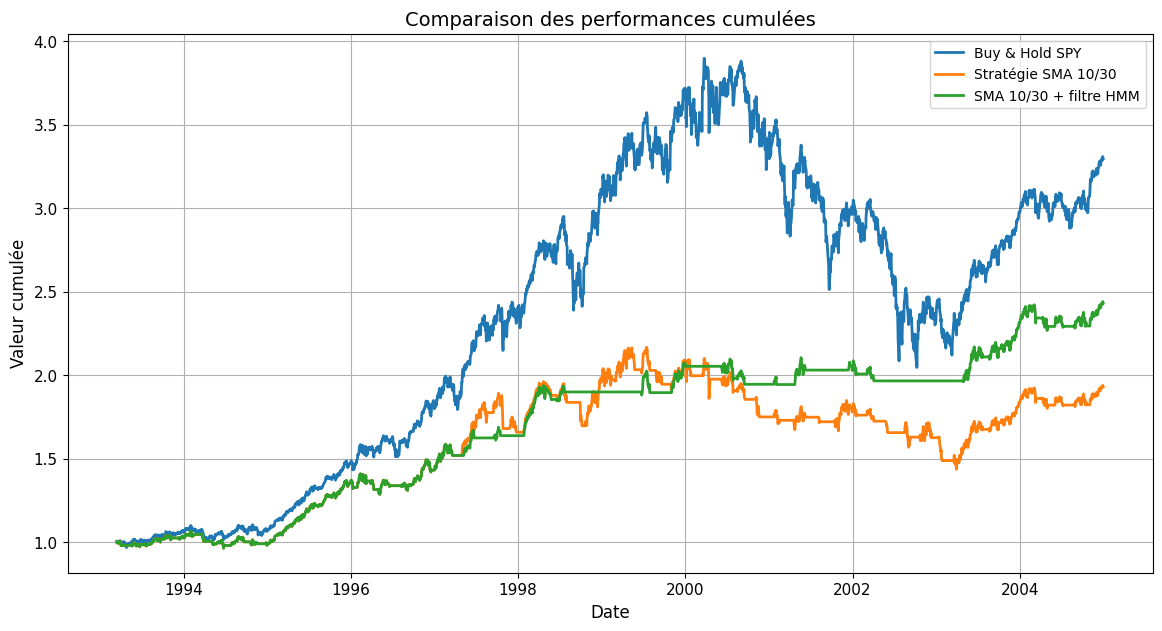

In [33]:
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(bt.index, bt["Equity_BuyHold"], label="Buy & Hold SPY", linewidth=2)
ax.plot(bt.index, bt["Equity_SMA"], label="Stratégie SMA 10/30", linewidth=2)
ax.plot(bt.index, bt["Equity_Filtered"], label="SMA 10/30 + filtre HMM", linewidth=2)

ax.set_title("Comparaison des performances cumulées")
ax.set_xlabel("Date")
ax.set_ylabel("Valeur cumulée")
ax.legend()
ax.xaxis.set_major_locator(YearLocator(2))
ax.xaxis.set_major_formatter(DateFormatter("%Y"))

plt.show()

## Analyse du temps passé investi

Le filtre de régime a aussi pour effet de réduire le temps passé sur le marché.

Nous allons mesurer la proportion de jours pendant lesquels chaque stratégie est effectivement investie :

- la stratégie SMA sans filtre ;
- la stratégie SMA avec filtre HMM.

In [34]:
exposure_sma = bt["Signal_SMA"].mean()
exposure_filtered = bt["Signal_Filtered"].mean()

print(f"Exposition moyenne stratégie SMA seule      : {exposure_sma:.2%}")
print(f"Exposition moyenne stratégie filtrée HMM    : {exposure_filtered:.2%}")

Exposition moyenne stratégie SMA seule      : 63.23%
Exposition moyenne stratégie filtrée HMM    : 48.03%


## Statistiques de performance simples

Afin de comparer plus rigoureusement les deux versions de la stratégie, nous allons calculer quelques indicateurs simples :

- le rendement cumulé final ;
- le rendement journalier moyen ;
- la volatilité journalière ;
- un Sharpe ratio simplifié, sans taux sans risque.

Le Sharpe ratio simplifié est défini ici par :

$$
Sharpe = \frac{\mathbb{E}[r]}{\sigma(r)} \times \sqrt{252}
$$

où :

- $\mathbb{E}[r]$ est le rendement journalier moyen ;
- $\sigma(r)$ est l'écart-type des rendements journaliers ;
- $252$ représente le nombre approximatif de jours de bourse par an.

In [35]:
def performance_summary(returns):
    returns = returns.dropna()
    cumulative_return = (1 + returns).prod() - 1
    mean_daily = returns.mean()
    vol_daily = returns.std()
    sharpe = (mean_daily / vol_daily) * np.sqrt(252) if vol_daily != 0 else np.nan
    
    return pd.Series({
        "Rendement cumulé": cumulative_return,
        "Rendement journalier moyen": mean_daily,
        "Volatilité journalière": vol_daily,
        "Sharpe simplifié": sharpe
    })

summary_table = pd.DataFrame({
    "Buy & Hold": performance_summary(bt["Returns"]),
    "SMA 10/30": performance_summary(bt["Strategy_Returns_SMA"]),
    "SMA 10/30 + HMM": performance_summary(bt["Strategy_Returns_Filtered"])
})

summary_table

,Buy & Hold,SMA 10/30,SMA 10/30 + HMM
Rendement cumulé,2.295611,0.930387,1.430405
Rendement journalier moyen,0.000465,0.000249,0.000311
Volatilité journalière,0.011283,0.007467,0.005042
Sharpe simplifié,0.653646,0.529437,0.979960


## Lecture des résultats

À ce stade, nous pouvons comparer directement les trois approches.

Les points importants à observer sont :

- le niveau final de performance cumulée ;
- la volatilité de la stratégie ;
- l'amélioration éventuelle du ratio de Sharpe ;
- la réduction de l'exposition au marché grâce au filtre.

Si le filtre HMM remplit bien son rôle, on s'attend en général à observer :

- moins de temps investi ;
- une réduction de l'exposition aux phases les plus agitées ;
- une amélioration potentielle du profil rendement / risque.

Il est toutefois possible que la performance brute ne soit pas toujours supérieure sur tous les sous-échantillons.  
L'intérêt principal du filtre est surtout de modifier la qualité du risque pris par la stratégie.

In [36]:
summary_table.style.format({
    "Rendement cumulé": "{:.2%}",
    "Rendement journalier moyen": "{:.4%}",
    "Volatilité journalière": "{:.4%}",
    "Sharpe simplifié": "{:.2f}"
})

,Buy & Hold,SMA 10/30,SMA 10/30 + HMM
Rendement cumulé,2.295611,0.930387,1.430405
Rendement journalier moyen,0.000465,0.000249,0.000311
Volatilité journalière,0.011283,0.007467,0.005042
Sharpe simplifié,0.653646,0.529437,0.979960


## Interprétation des résultats de la stratégie

Nous pouvons maintenant comparer les trois approches étudiées :

- **Buy \& Hold SPY**
- **Stratégie SMA 10/30**
- **Stratégie SMA 10/30 avec filtre HMM**

### 1. Lecture de la performance cumulée

Les valeurs finales obtenues à la fin de la période d'entraînement sont :

- **Buy \& Hold** : $3.295611$
- **SMA 10/30** : $1.930387$
- **SMA 10/30 + HMM** : $2.430405$

Cela signifie que :

- un investissement passif sur le SPY transforme approximativement 1 en **3.30** ;
- la stratégie de moyennes mobiles seule transforme 1 en **1.93** ;
- la stratégie filtrée par le HMM transforme 1 en **2.43**.

On observe donc que :

- la stratégie SMA seule sous-performe nettement le Buy \& Hold ;
- l'ajout du filtre HMM améliore sensiblement la stratégie SMA ;
- toutefois, sur cette période, le Buy \& Hold reste la meilleure approche en performance brute.

### 2. Effet du filtre de régime

Le rôle du filtre n'est pas nécessairement de battre systématiquement un investissement passif, mais plutôt de **réduire l'exposition aux régimes défavorables**.

Ici, le HMM identifie :

- le **régime 0** comme régime de faible volatilité ;
- le **régime 1** comme régime de forte volatilité.

La stratégie filtrée n'autorise donc les positions longues que lorsque :

$$
SMA_{10}(t) > SMA_{30}(t)
\quad \text{et} \quad
State_t = 0
$$

Autrement dit, le filtre HMM sert à éviter les prises de position pendant les phases de marché les plus instables.

### 3. Analyse du tableau de performance

Les statistiques obtenues sont les suivantes :

#### Buy \& Hold
- rendement cumulé : $2.295611$
- rendement journalier moyen : $0.000465$
- volatilité journalière : $0.011283$
- Sharpe simplifié : $0.653646$

#### SMA 10/30
- rendement cumulé : $0.930387$
- rendement journalier moyen : $0.000249$
- volatilité journalière : $0.007467$
- Sharpe simplifié : $0.529437$

#### SMA 10/30 + HMM
- rendement cumulé : $1.430405$
- rendement journalier moyen : $0.000311$
- volatilité journalière : $0.005042$
- Sharpe simplifié : $0.979960$

### 4. Conclusion financière

Le résultat le plus important ici concerne le **profil rendement / risque**.

Même si la stratégie filtrée ne bat pas le Buy \& Hold en rendement brut, elle présente :

- une **volatilité beaucoup plus faible** ;
- un **Sharpe ratio nettement supérieur** ;
- une meilleure qualité de performance que la stratégie SMA seule.

On remarque notamment que :

$$
0.979960 > 0.653646 > 0.529437
$$

Le meilleur Sharpe ratio est donc obtenu par la stratégie :

$$
\text{SMA 10/30 + filtre HMM}
$$

Cela signifie que, sur cette période, le filtre de régime améliore fortement l'efficacité du risque pris.

### 5. Lecture économique

Ces résultats sont cohérents avec l'objectif initial :

- la SMA seule produit un signal directionnel simple, mais reste vulnérable aux périodes de turbulence ;
- le HMM permet d'identifier les phases de marché plus agitées ;
- en excluant ces phases, on améliore la robustesse de la stratégie.

Ainsi, le modèle HMM agit bien comme un **filtre de risque**, et non comme un simple outil prédictif de performance brute.

### 6. Bilan intermédiaire

Sur l'échantillon étudié :

- le **Buy \& Hold** domine en rendement absolu ;
- la **SMA 10/30 + HMM** domine en qualité de performance ajustée du risque ;
- la **SMA 10/30 seule** est la moins convaincante des trois approches.

C'est exactement le type de conclusion que l'on cherchait à mettre en évidence avec cette méthodologie.

## Visualisation des régimes en arrière-plan

Pour améliorer la lisibilité, nous allons maintenant représenter les régimes de marché directement en arrière-plan du graphique de prix.

L'idée est simple :

- colorer légèrement les périodes de **faible volatilité** ;
- colorer différemment les périodes de **forte volatilité**.

Cette représentation permet de visualiser plus clairement le lien entre :

- l'évolution du prix ;
- les changements de régime détectés par le HMM ;
- le comportement de la stratégie.

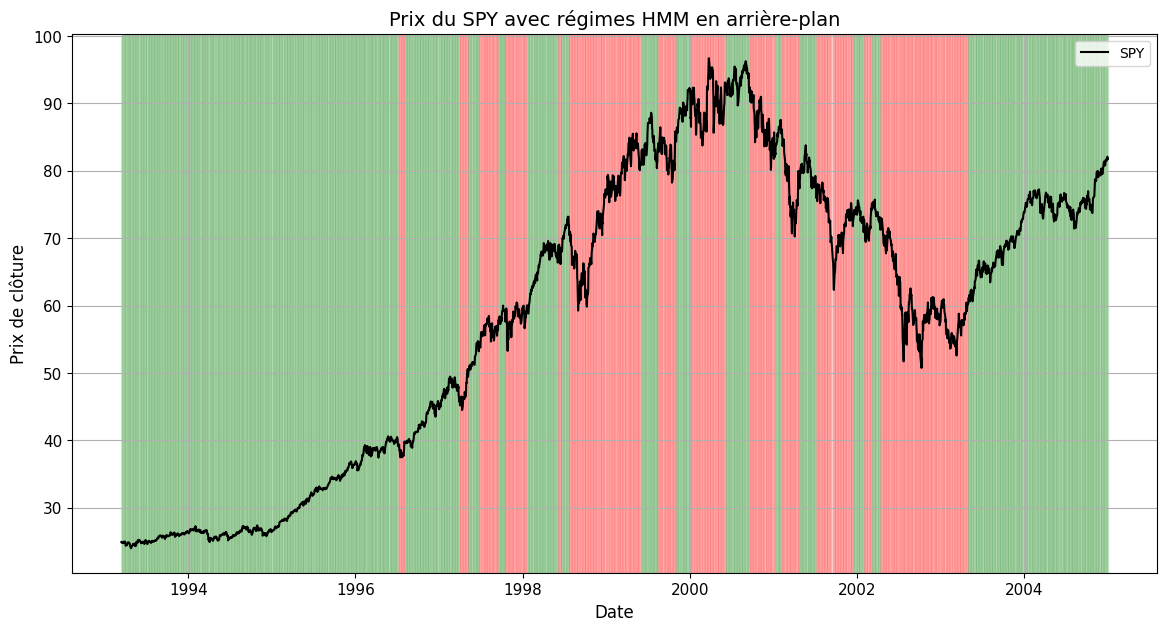

In [37]:
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(bt.index, bt["Close"], color="black", linewidth=1.5, label="SPY")

for i in range(len(bt) - 1):
    start = bt.index[i]
    end = bt.index[i + 1]
    state = bt["State"].iloc[i]
    
    if state == low_vol_state:
        ax.axvspan(start, end, alpha=0.08, color="green")
    else:
        ax.axvspan(start, end, alpha=0.08, color="red")

ax.set_title("Prix du SPY avec régimes HMM en arrière-plan")
ax.set_xlabel("Date")
ax.set_ylabel("Prix de clôture")
ax.legend()
ax.xaxis.set_major_locator(YearLocator(2))
ax.xaxis.set_major_formatter(DateFormatter("%Y"))

plt.show()

## Analyse du drawdown

Le drawdown mesure la perte relative par rapport au plus haut historique atteint par une stratégie.

Si l'on note $V_t$ la valeur cumulée d'une stratégie, alors le drawdown à la date $t$ est défini par :

$$
DD_t = \frac{V_t}{\max_{s \le t} V_s} - 1
$$

Le drawdown est un indicateur très important en gestion d'actifs, car il mesure la profondeur des pertes subies après un sommet.

Nous allons comparer les drawdowns :

- du Buy \& Hold ;
- de la stratégie SMA ;
- de la stratégie SMA filtrée par le HMM.

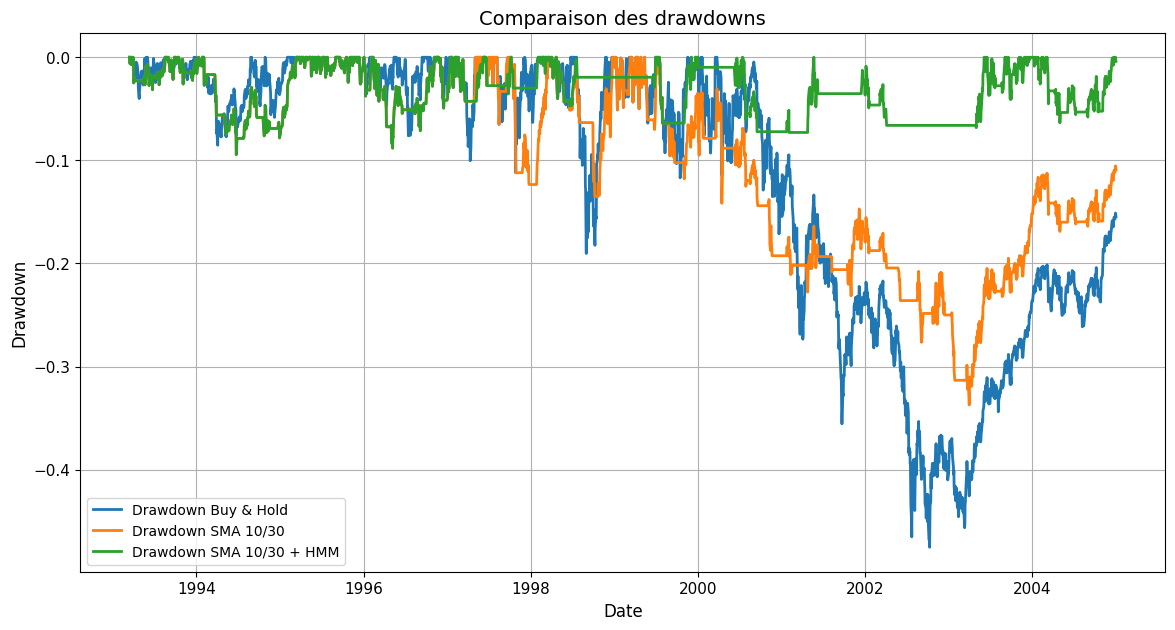

In [38]:
def compute_drawdown(equity_curve):
    running_max = equity_curve.cummax()
    drawdown = equity_curve / running_max - 1.0
    return drawdown

bt["DD_BuyHold"] = compute_drawdown(bt["Equity_BuyHold"])
bt["DD_SMA"] = compute_drawdown(bt["Equity_SMA"])
bt["DD_Filtered"] = compute_drawdown(bt["Equity_Filtered"])

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(bt.index, bt["DD_BuyHold"], label="Drawdown Buy & Hold", linewidth=2)
ax.plot(bt.index, bt["DD_SMA"], label="Drawdown SMA 10/30", linewidth=2)
ax.plot(bt.index, bt["DD_Filtered"], label="Drawdown SMA 10/30 + HMM", linewidth=2)

ax.set_title("Comparaison des drawdowns")
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown")
ax.legend()
ax.xaxis.set_major_locator(YearLocator(2))
ax.xaxis.set_major_formatter(DateFormatter("%Y"))

plt.show()

## Maximum drawdown

Nous allons maintenant calculer le drawdown maximal de chaque approche, c'est-à-dire la pire perte relative subie depuis un plus haut historique.

Le maximum drawdown est donné par :

$$
MDD = \min_t(DD_t)
$$

Plus cette valeur est faible en valeur absolue, plus la stratégie est robuste face aux phases de repli.

In [39]:
max_dd = pd.Series({
    "Buy & Hold": bt["DD_BuyHold"].min(),
    "SMA 10/30": bt["DD_SMA"].min(),
    "SMA 10/30 + HMM": bt["DD_Filtered"].min()
})

max_dd

Buy & Hold        -0.475159
SMA 10/30         -0.337206
SMA 10/30 + HMM   -0.094462
dtype: float64

In [40]:
max_dd.to_frame(name="Maximum Drawdown").style.format("{:.2%}")

,Maximum Drawdown
Buy & Hold,-47.52%
SMA 10/30,-33.72%
SMA 10/30 + HMM,-9.45%


## Interprétation des drawdowns et des régimes en arrière-plan

Les nouveaux graphiques confirment très clairement l'intérêt du filtre HMM.

### 1. Lecture du graphique avec régimes en arrière-plan

Le graphique du prix du SPY, combiné aux régimes colorés, permet de mieux visualiser le comportement du marché selon l'état détecté par le HMM :

- les zones **vertes** correspondent au régime de **faible volatilité** ;
- les zones **rouges** correspondent au régime de **forte volatilité**.

On observe que :

- les périodes les plus stables du marché sont majoritairement classées dans le régime calme ;
- les périodes plus instables, notamment autour de la phase de correction du début des années 2000, sont plus souvent classées dans le régime turbulent ;
- le modèle ne segmente pas uniquement le marché par tendance haussière ou baissière, mais surtout par **niveau de risque**.

C'est un point important : le HMM ne cherche pas ici à dire si le marché va monter ou baisser, mais à identifier si l'environnement de marché est **favorable ou non à la prise de risque**.

### 2. Lecture des drawdowns

Le graphique des drawdowns montre une différence très forte entre les trois approches.

Les maximum drawdowns obtenus sont :

- **Buy \& Hold** : $-47.52\%$
- **SMA 10/30** : $-33.72\%$
- **SMA 10/30 + HMM** : $-9.45\%$

Autrement dit :

$$
|{-9.45\%}| \ll |{-33.72\%}| \ll |{-47.52\%}|
$$

La stratégie filtrée par le HMM subit donc une perte maximale **très largement inférieure** aux deux autres approches.

### 3. Interprétation financière

Ce résultat est extrêmement important.

Le filtre HMM permet ici de réduire fortement les pertes subies lors des phases difficiles de marché.  
En pratique, cela signifie que la stratégie :

- reste plus souvent en dehors du marché pendant les périodes instables ;
- évite une partie des séquences les plus destructrices ;
- conserve une trajectoire de performance beaucoup plus régulière.

Le fait d'obtenir un maximum drawdown inférieur à $10\%$ est particulièrement remarquable par rapport :

- au Buy \& Hold, qui subit presque $50\%$ de baisse au pire moment ;
- à la stratégie SMA seule, qui reste elle aussi exposée à des pertes importantes.

### 4. Cohérence avec les résultats précédents

Ces résultats complètent parfaitement l'analyse précédente :

- la stratégie filtrée ne bat pas le Buy \& Hold en rendement brut ;
- mais elle améliore nettement le **profil de risque** ;
- elle affiche déjà le meilleur **Sharpe ratio** ;
- et elle présente maintenant de très loin le meilleur **maximum drawdown**.

Cela renforce l'idée centrale du notebook :

> le filtre de régime HMM n'est pas conçu pour maximiser uniquement la performance brute, mais pour améliorer la qualité globale de la stratégie en réduisant l'exposition aux environnements les plus dangereux.

### 5. Conclusion

À ce stade, la stratégie **SMA 10/30 + HMM** apparaît comme la version la plus robuste des trois approches testées.

Elle combine :

- une volatilité plus faible ;
- un meilleur Sharpe ratio ;
- un drawdown maximal très réduit ;
- une trajectoire de capital beaucoup plus stable.

La suite logique consiste maintenant à visualiser plus finement la stratégie elle-même, en affichant directement sur le prix :

- les périodes où la stratégie est investie ;
- éventuellement les points d'entrée ;
- éventuellement les points de sortie.

Cela permettra de mieux comprendre comment le filtre agit concrètement sur les décisions de trading.

## Visualisation des signaux de trading

Pour mieux comprendre le comportement de la stratégie, nous allons maintenant afficher :

- le prix du SPY ;
- la moyenne mobile à 10 jours ;
- la moyenne mobile à 30 jours ;
- les points d'entrée en position ;
- les points de sortie.

Nous allons nous concentrer sur la stratégie **filtrée par le HMM**, car c'est elle qui présente le meilleur profil de risque.

L'idée est de visualiser concrètement à quels moments la stratégie décide :

- d'entrer sur le marché ;
- de sortir du marché ;
- et comment ces décisions s'articulent avec les régimes de marché détectés.

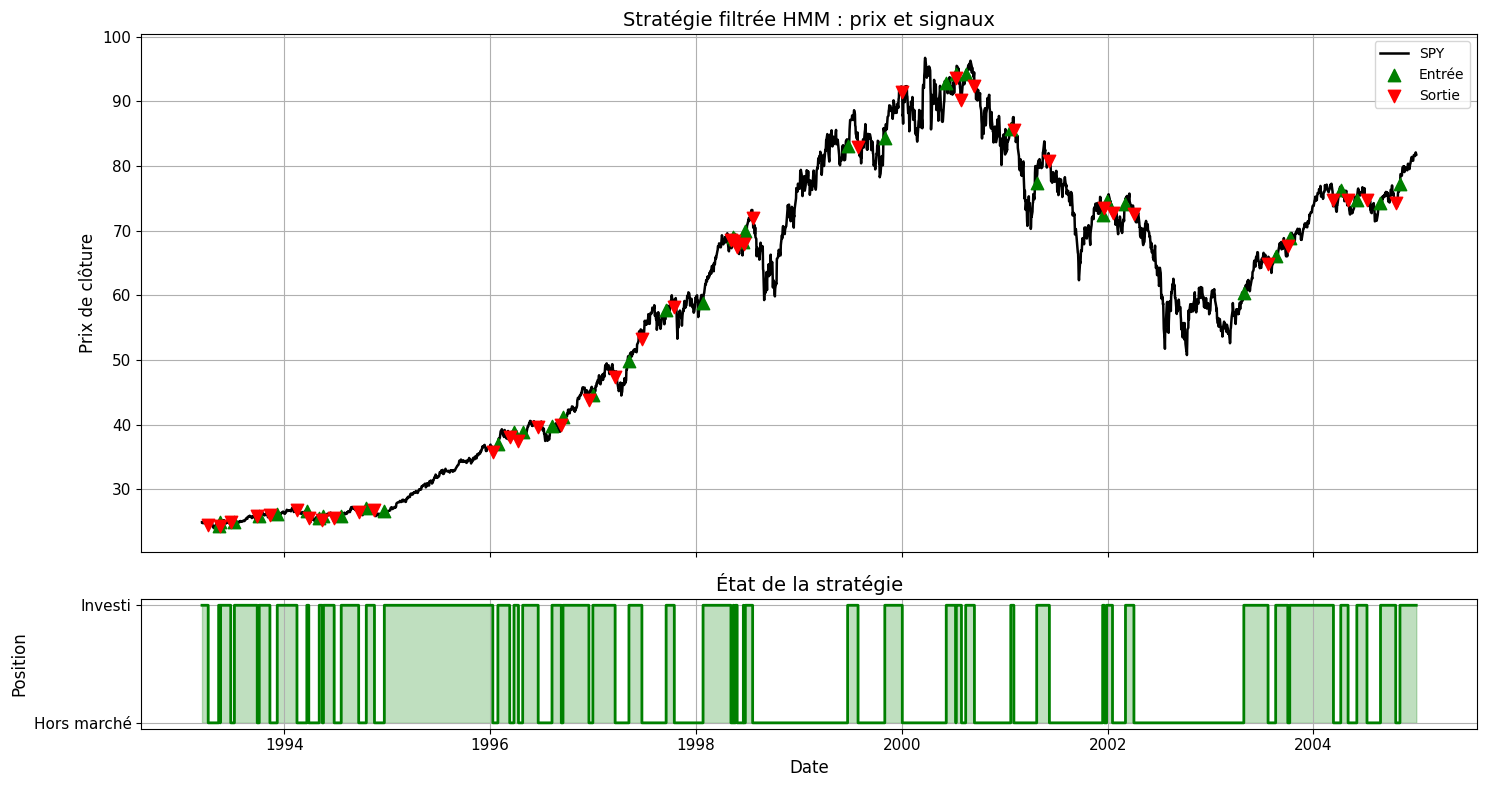

In [43]:
buy_signals = bt[bt["Position_Change"] == 1]
sell_signals = bt[bt["Position_Change"] == -1]

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(15, 8), sharex=True,
    gridspec_kw={"height_ratios": [4, 1]}
)

# --- Graphe du haut : prix + signaux ---
ax1.plot(bt.index, bt["Close"], color="black", linewidth=1.8, label="SPY")

ax1.scatter(
    buy_signals.index,
    buy_signals["Close"],
    marker="^",
    s=80,
    color="green",
    label="Entrée",
    zorder=3
)

ax1.scatter(
    sell_signals.index,
    sell_signals["Close"],
    marker="v",
    s=80,
    color="red",
    label="Sortie",
    zorder=3
)

ax1.set_title("Stratégie filtrée HMM : prix et signaux")
ax1.set_ylabel("Prix de clôture")
ax1.legend()

# --- Graphe du bas : état investi / non investi ---
ax2.step(
    bt.index,
    bt["Signal_Filtered"],
    where="post",
    linewidth=2,
    color="green"
)

ax2.fill_between(
    bt.index,
    0,
    bt["Signal_Filtered"],
    step="post",
    alpha=0.25,
    color="green"
)

ax2.set_title("État de la stratégie")
ax2.set_ylabel("Position")
ax2.set_yticks([0, 1])
ax2.set_yticklabels(["Hors marché", "Investi"])
ax2.set_xlabel("Date")

ax2.xaxis.set_major_locator(YearLocator(2))
ax2.xaxis.set_major_formatter(DateFormatter("%Y"))

plt.tight_layout()
plt.show()

## Visualisation détaillée sur trois sous-périodes

Pour améliorer la lisibilité, nous découpons maintenant l'échantillon en trois sous-périodes couvrant ensemble toute la période d'étude.

L'objectif est de conserver la même logique graphique que précédemment :

- en haut : le prix du SPY avec les signaux d'entrée et de sortie ;
- en bas : l'état de la stratégie, c'est-à-dire :
  - $1$ si la stratégie est investie ;
  - $0$ sinon.

Cette représentation permet de lire plus clairement les décisions de trading sur des fenêtres temporelles plus courtes.

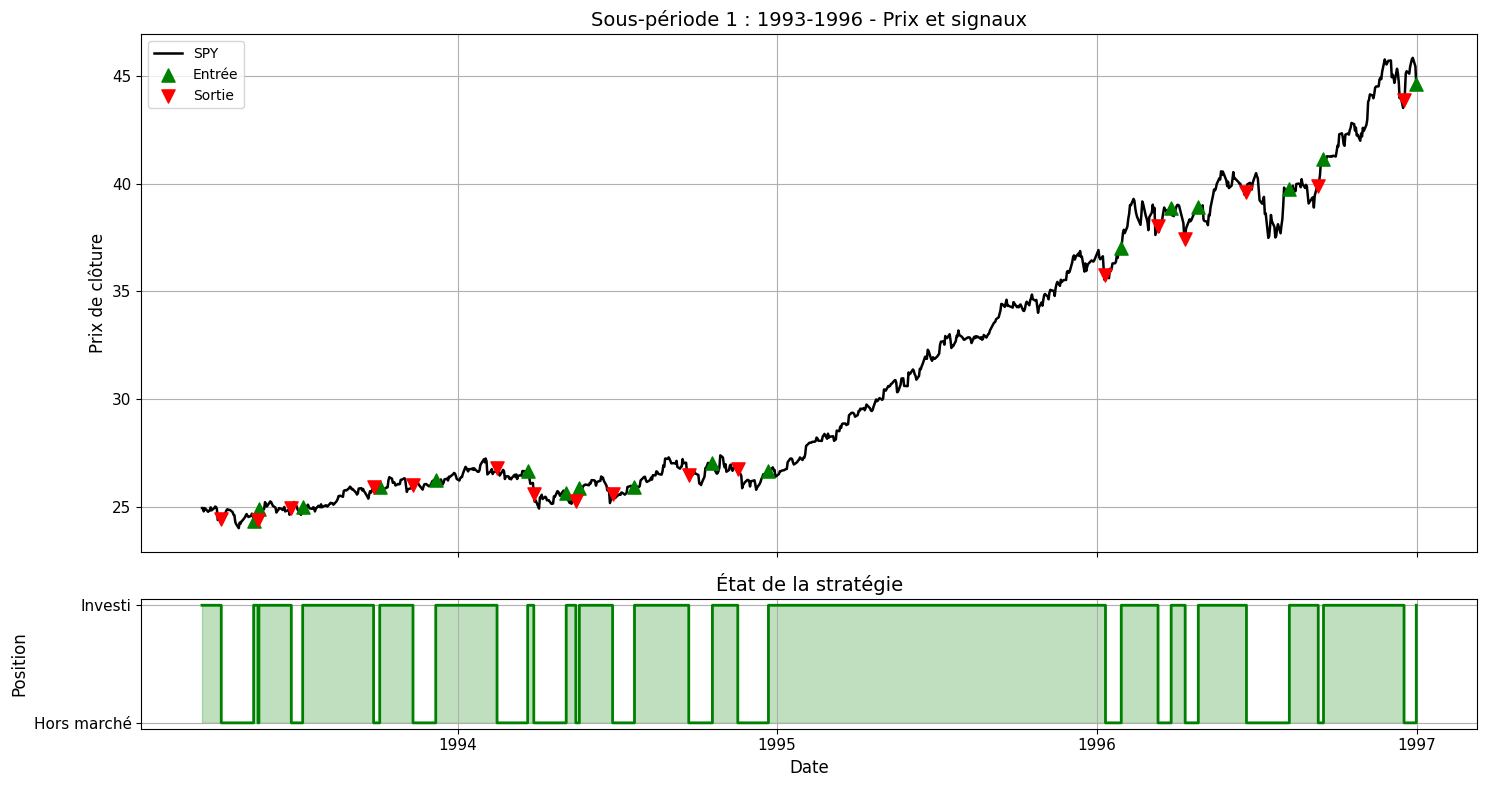

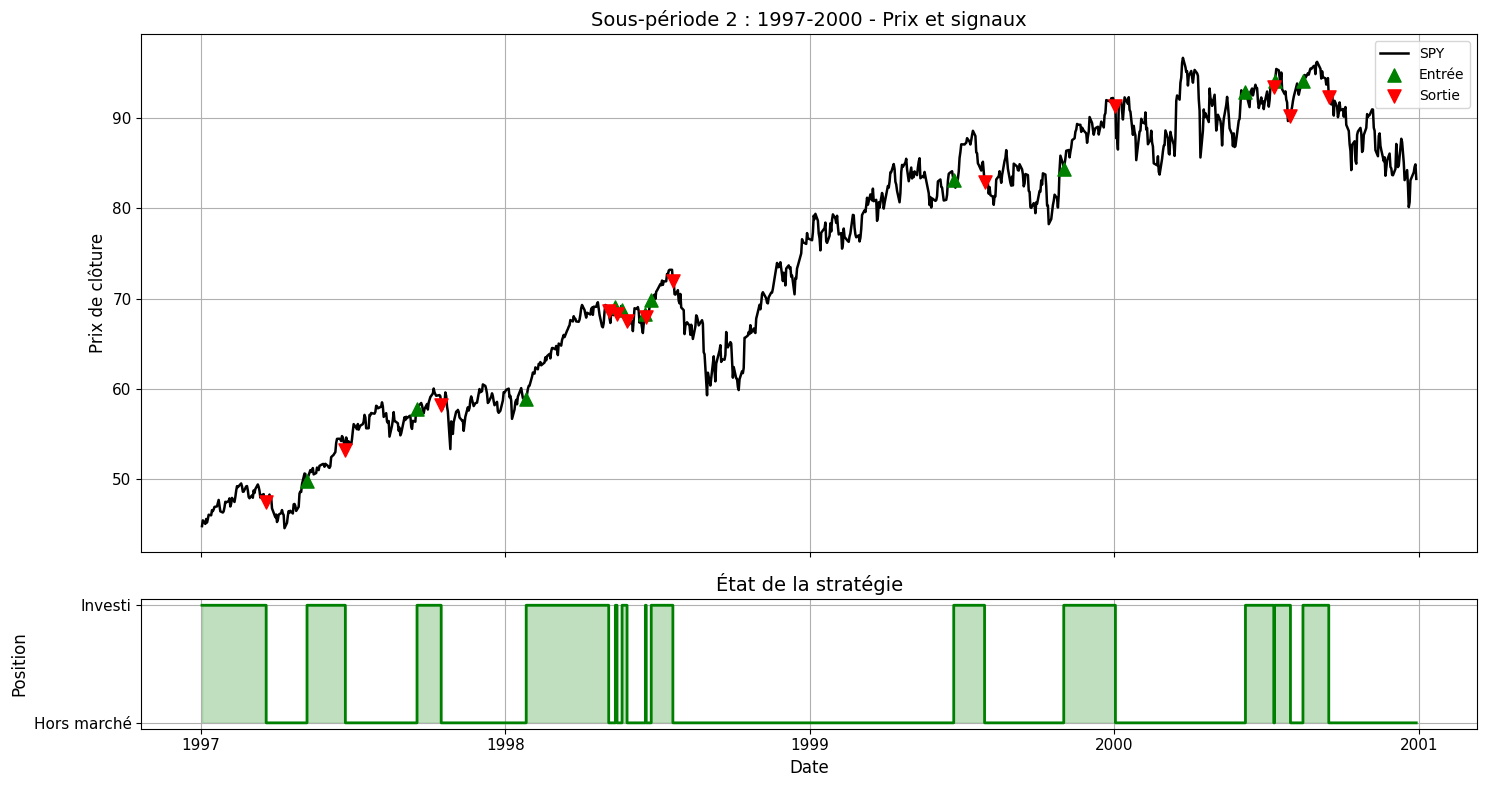

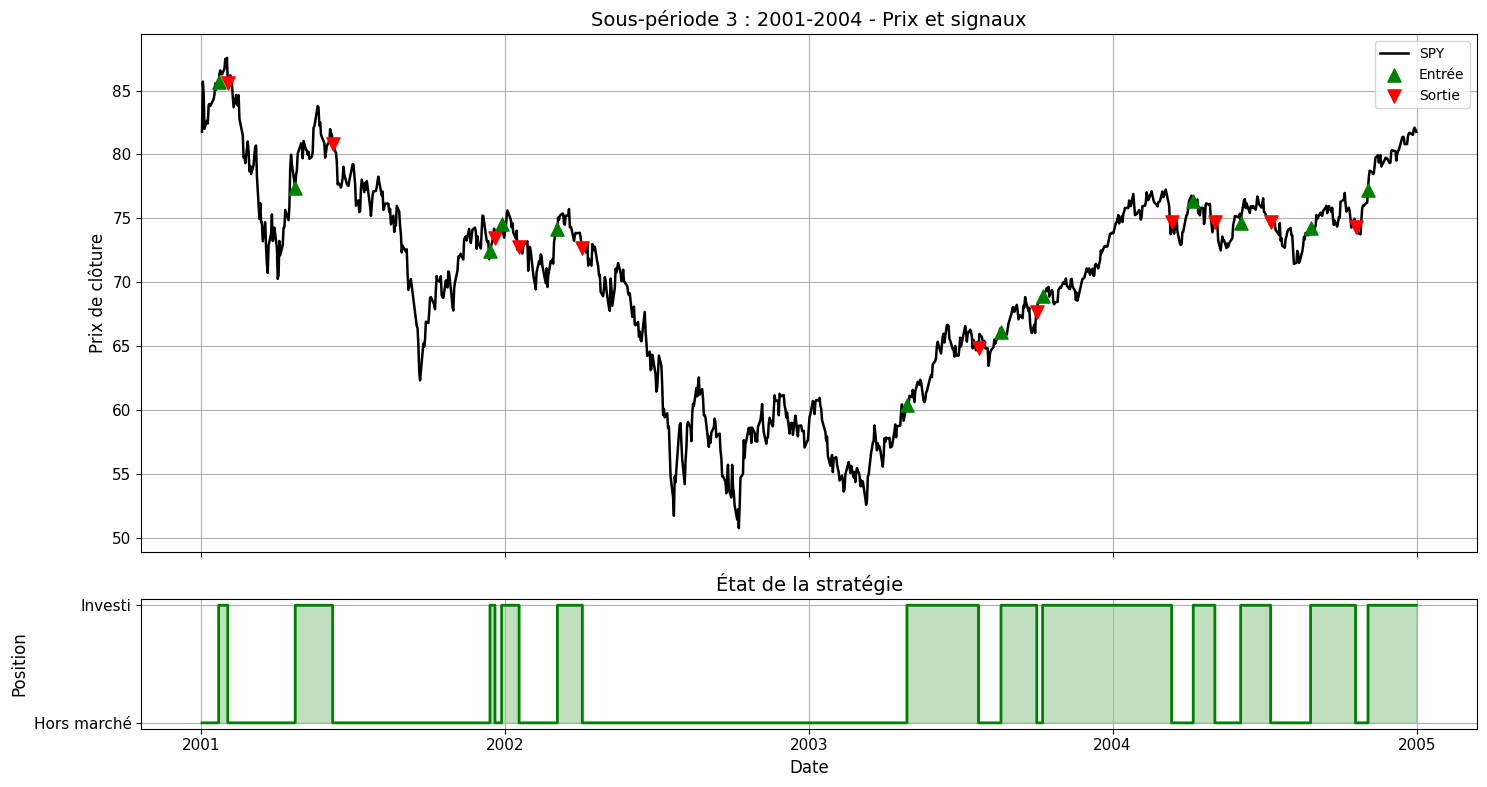

In [45]:
periods = [
    ("1993-02-01", "1996-12-31", "Sous-période 1 : 1993-1996"),
    ("1997-01-01", "2000-12-31", "Sous-période 2 : 1997-2000"),
    ("2001-01-01", "2004-12-31", "Sous-période 3 : 2001-2004"),
]

for start, end, title in periods:
    bt_zoom = bt.loc[start:end].copy()
    buy_zoom = buy_signals.loc[start:end]
    sell_zoom = sell_signals.loc[start:end]

    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(15, 8),
        sharex=True,
        gridspec_kw={"height_ratios": [4, 1]}
    )

    # --- Panneau supérieur : prix + signaux ---
    ax1.plot(bt_zoom.index, bt_zoom["Close"], color="black", linewidth=1.8, label="SPY")

    ax1.scatter(
        buy_zoom.index,
        buy_zoom["Close"],
        marker="^",
        s=90,
        color="green",
        label="Entrée",
        zorder=3
    )

    ax1.scatter(
        sell_zoom.index,
        sell_zoom["Close"],
        marker="v",
        s=90,
        color="red",
        label="Sortie",
        zorder=3
    )

    ax1.set_title(f"{title} - Prix et signaux")
    ax1.set_ylabel("Prix de clôture")
    ax1.legend()

    # --- Panneau inférieur : état de la stratégie ---
    ax2.step(
        bt_zoom.index,
        bt_zoom["Signal_Filtered"],
        where="post",
        linewidth=2,
        color="green"
    )

    ax2.fill_between(
        bt_zoom.index,
        0,
        bt_zoom["Signal_Filtered"],
        step="post",
        alpha=0.25,
        color="green"
    )

    ax2.set_title("État de la stratégie")
    ax2.set_ylabel("Position")
    ax2.set_yticks([0, 1])
    ax2.set_yticklabels(["Hors marché", "Investi"])
    ax2.set_xlabel("Date")

    ax2.xaxis.set_major_locator(YearLocator(1))
    ax2.xaxis.set_major_formatter(DateFormatter("%Y"))

    plt.tight_layout()
    plt.show()

## Conclusion générale

Dans ce notebook, nous avons reproduit l'idée principale de l'article : utiliser un **Hidden Markov Model (HMM)** pour détecter des **régimes de marché** et s'en servir comme **filtre de risque** dans une stratégie de trading simple.

### Récapitulatif des étapes

Nous avons procédé de la manière suivante :

1. récupération des données historiques du **SPY** ;
2. calcul des rendements journaliers ;
3. entraînement d'un **Gaussian HMM** à deux états ;
4. identification d'un régime de **faible volatilité** et d'un régime de **forte volatilité** ;
5. construction d'une stratégie de suivi de tendance basée sur :
   - une **SMA 10 jours** ;
   - une **SMA 30 jours** ;
6. ajout d'un filtre de régime autorisant les positions uniquement dans le régime le plus calme ;
7. comparaison des performances, de la volatilité, du Sharpe ratio et du maximum drawdown.

### Résultats principaux

L'analyse a montré que :

- la stratégie **SMA 10/30 seule** reste relativement peu performante ;
- l'ajout du **filtre HMM** améliore nettement son comportement ;
- le principal gain n'est pas uniquement un gain de rendement brut, mais surtout une **amélioration du profil rendement / risque**.

En particulier, la stratégie filtrée présente :

- une volatilité plus faible ;
- un Sharpe ratio plus élevé ;
- un maximum drawdown très fortement réduit.

### Interprétation financière

Le résultat obtenu illustre une idée importante en finance quantitative :

> une stratégie peut être améliorée non seulement en modifiant ses signaux, mais aussi en sélectionnant les environnements de marché dans lesquels elle est autorisée à intervenir.

Ici, le HMM n'est pas utilisé comme outil de prévision directe du prix, mais comme outil de **détection de contexte de marché**.

La stratégie finale ne cherche donc pas à être investie en permanence.  
Elle privilégie les périodes où :

- la dynamique de tendance est favorable ;
- et le régime de volatilité semble plus calme.

### Bilan

Sur la période étudiée, le **Buy \& Hold** reste la meilleure approche en performance brute.  
En revanche, la stratégie **SMA 10/30 + filtre HMM** apparaît comme la plus robuste du point de vue de la gestion du risque.

C'est précisément ce qui fait l'intérêt de cette approche.

## Limites de l'approche

Même si les résultats obtenus sont intéressants, cette méthode présente plusieurs limites.

### 1. Nombre de régimes fixé à l'avance

Nous avons imposé un modèle à deux régimes :

$$
K = 2
$$

Ce choix est simple, mais il est possible que le marché présente davantage de structures :

- régime calme haussier ;
- régime calme baissier ;
- régime très volatil ;
- régime de transition.

Le choix du nombre d'états influence donc fortement les résultats.

### 2. Variable observée trop simple

Le HMM a été entraîné uniquement sur les rendements journaliers.  
Or les régimes de marché peuvent aussi dépendre d'autres variables, comme :

- la volatilité réalisée ;
- les volumes ;
- le VIX ;
- les spreads de crédit ;
- des indicateurs macro-financiers.

Une modélisation plus riche nécessiterait donc plusieurs variables observées.

### 3. Pas de véritable séparation in-sample / out-of-sample

Dans ce notebook, nous avons surtout illustré le mécanisme sur une période donnée.  
Pour une vraie validation quantitative, il faudrait distinguer :

- une période d'entraînement ;
- une période de test hors échantillon.

Cela permettrait de vérifier si le filtre reste efficace sur des données non utilisées lors du calibrage.

### 4. Coûts de transaction ignorés

La stratégie ne prend pas en compte :

- les frais de transaction ;
- le bid-ask spread ;
- les éventuels coûts de slippage.

Or ces coûts peuvent réduire sensiblement la performance d'une stratégie active.

### 5. Hypothèses simplificatrices du HMM

Le modèle suppose ici :

- une dynamique markovienne des régimes ;
- des observations gaussiennes conditionnelles au régime.

Ces hypothèses sont pratiques, mais elles restent une approximation de la réalité financière.

## Pistes d'amélioration

Ce travail peut être prolongé de plusieurs manières.

### 1. Tester plusieurs nombres d'états

Une première extension naturelle consiste à comparer plusieurs valeurs de $K$, par exemple :

$$
K \in \{2, 3, 4\}
$$

afin de voir si une structure plus fine des régimes améliore l'analyse.

### 2. Construire un HMM multivarié

On pourrait enrichir le modèle en ajoutant d'autres variables observées, par exemple :

- rendement ;
- volatilité réalisée ;
- volume ;
- drawdown récent ;
- indicateurs de marché externes.

Cela permettrait de détecter des régimes plus réalistes.

### 3. Tester d'autres règles de trading

La stratégie SMA 10/30 utilisée ici est volontairement simple.  
On pourrait tester :

- d'autres fenêtres de moyennes mobiles ;
- des stratégies de momentum ;
- des stratégies de breakout ;
- des filtres combinés avec volatilité ou trend strength.

### 4. Réaliser un vrai backtest hors échantillon

Une amélioration essentielle serait de mettre en place une logique complète de validation :

- entraînement sur une première période ;
- prédiction des régimes sur une seconde période ;
- comparaison des performances hors échantillon.

### 5. Ajouter des mesures de risque plus avancées

Il serait également intéressant d'ajouter :

- le Calmar ratio ;
- la Value-at-Risk ;
- la Conditional Value-at-Risk ;
- l'analyse de la durée moyenne des drawdowns.

### 6. Intégrer les coûts de transaction

Enfin, une version plus réaliste du backtest devrait intégrer les coûts de trading afin d'évaluer la performance nette réellement exploitable.